# Loading an ensemble of FALL3D forecasts
***

Results from FALL3D simulations are stored in [netCDF][netcdf] format

In order to open and manipulate data from netCDF files, we can use the python package `xarray`. In order to create maps from the data, a popular option is `matplotlib` along with `Cartopy`, a Python package designed for geospatial data processing in order to produce maps and other geospatial data analyses.

Some example of Python scripts can be found in the [FALL3D user guide][fall3d].

<div class="alert alert-block alert-info">
<b>NetCDF:</b> 
    
NetCDF (network Common Data Form) is an open-source file format and associated software libraries for creating, accessing, and sharing scientific data, particularly multidimensional arrays like meteorological variables
</div>

[netcdf]: https://www.unidata.ucar.edu/software/netcdf "netCDF"
[fall3d]: https://fall3d-suite.gitlab.io/fall3d/hands-on/introduction.html "FALL3D user guide"

## Importing modules

In [5]:
import xarray as xr                              # multi-dimensional arrays for NetCDF data
import numpy as np                               # numerical operations on arrays
import matplotlib.pyplot as plt                  # plots and visualizations
import cartopy.crs as crs                        # coordinate systems for maps
import cartopy.feature as cfeature

## Loading data and inspecting file structure

The N-dimensional nature of Xarray’s data structures makes it suitable for dealing with multi-dimensional scientific data, and its use of dimension names instead of axis labels (`dim='time'` instead of `axis=0`) makes such arrays much more manageable.

Here is an example of how we might structure a dataset for a weather forecast:

![](https://docs.xarray.dev/en/stable/_images/dataset-diagram.png)

In [2]:
# Open a netCDF file in a xarray dataset
fname = "data/final.ens.nc"
ds = xr.open_dataset(fname)

# Let's see the structure of the data
ds

<xarray.Dataset> Size: 1GB
Dimensions:                        (time: 26, ens: 256, lat: 101, lon: 121,
                                    intensity_measure_con: 1,
                                    intensity_measure_col_mass: 1,
                                    intensity_measure_col_mass_DU: 1,
                                    intensity_measure_grn_load: 1,
                                    exceedance_probability: 1)
Coordinates:
  * lon                            (lon) float32 484B -22.0 -21.9 ... -10.0
  * lat                            (lat) float32 404B 22.0 22.1 ... 31.9 32.0
  * intensity_measure_con          (intensity_measure_con) float32 4B 2.0
  * intensity_measure_col_mass     (intensity_measure_col_mass) float32 4B 0.2
  * intensity_measure_col_mass_DU  (intensity_measure_col_mass_DU) float32 4B ...
  * intensity_measure_grn_load     (intensity_measure_grn_load) float32 4B 1.0
  * exceedance_probability         (exceedance_probability) float32 4B 50.0
  * ens                            (ens) float32 1kB 1.0 2.0 3.0 ... 255.0 256.0
  * time                           (time) datetime64[ns] 208B 2025-09-26T09:0...
Data variables:
    date                           (time) |S64 2kB ...
    tephra_col_mass                (time, ens, lat, lon) float32 325MB ...
    tephra_col_mass_mean           (time, lat, lon) float32 1MB ...
    tephra_grn_load                (time, ens, lat, lon) float32 325MB ...
    tephra_grn_load_mean           (time, lat, lon) float32 1MB ...
    SO2_col_mass                   (time, ens, lat, lon) float32 325MB ...
    SO2_col_mass_mean              (time, lat, lon) float32 1MB ...
    SO2_grn_load                   (time, ens, lat, lon) float32 325MB ...
    SO2_grn_load_mean              (time, lat, lon) float32 1MB ...
Attributes:
    Title:                       FALL3D ensemble model results
    NetCDF_conventions:          NetCDF Climate and Forecast (CF) Metadata Co...
    NetCDF_conventions_version:  CF-1.8
    Code_suite_task:             Generated by PosEns task in FALL3D suite
    Code_version:                9.0.1-40-g287b935/master
    Code_version_url:            git@gitlab.com:fall3d-suite/fall3d.git
    Code_version_release_date:   Thu Aug 14 19:46:13 2025 +0200
    Code_version_licence:        GNU v3 see LICENSE file

## Selecting variables and indexing

In [3]:
# Selecting a single variable
da = ds['tephra_col_mass_mean']
da

<xarray.DataArray 'tephra_col_mass_mean' (time: 26, lat: 101, lon: 121)> Size: 1MB
[317746 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 484B -22.0 -21.9 -21.8 -21.7 ... -10.2 -10.1 -10.0
  * lat      (lat) float32 404B 22.0 22.1 22.2 22.3 22.4 ... 31.7 31.8 31.9 32.0
  * time     (time) datetime64[ns] 208B 2025-09-26T09:00:00 ... 2025-09-27T09...
Attributes:
    long_name:  tephra_ensemble mean column mass load
    units:      g/m2

In [4]:
# Indexing
da = ds['tephra_col_mass_mean'].isel(time=-1)
da

<xarray.DataArray 'tephra_col_mass_mean' (lat: 101, lon: 121)> Size: 49kB
[12221 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 484B -22.0 -21.9 -21.8 -21.7 ... -10.2 -10.1 -10.0
  * lat      (lat) float32 404B 22.0 22.1 22.2 22.3 22.4 ... 31.7 31.8 31.9 32.0
    time     datetime64[ns] 8B 2025-09-27T09:00:00
Attributes:
    long_name:  tephra_ensemble mean column mass load
    units:      g/m2

In [5]:
da.time

<xarray.DataArray 'time' ()> Size: 8B
array('2025-09-27T09:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2025-09-27T09:00:00
Attributes:
    long_name:    time
    start_year:   2025
    start_month:  9
    start_day:    26

## Saving data

In [6]:
## Saving a single variable for the last time step
da.to_netcdf("colmass.nc")

## Creating an empty map

In [6]:
def create_map(projection = crs.PlateCarree()):
    fig, ax = plt.subplots( subplot_kw={'projection': projection} )
    ###
    ### Add map features
    ###
    BORDERS = cfeature.NaturalEarthFeature(
            scale     = '10m',
            category  = 'cultural',
            name      = 'admin_0_countries',
            edgecolor = 'gray',
            facecolor = 'none'
            )
    LAND = cfeature.NaturalEarthFeature(
            'physical', 'land', '10m',
            edgecolor = 'none',
            facecolor = 'lightgrey',
            alpha     = 0.8
            )
    
    ax.add_feature(LAND,zorder=0)
    ax.add_feature(BORDERS, linewidth=0.4)
    ###
    ### Add grid lines
    ###
    gl = ax.gridlines(
        crs         = crs.PlateCarree(),
        draw_labels = True,
        linewidth   = 0.5,
        color       = 'gray',
        alpha       = 0.5,
        linestyle   = '--')
    gl.top_labels    = False
    gl.right_labels  = False
    gl.ylabel_style  = {'rotation': 90}
    
    return fig, ax

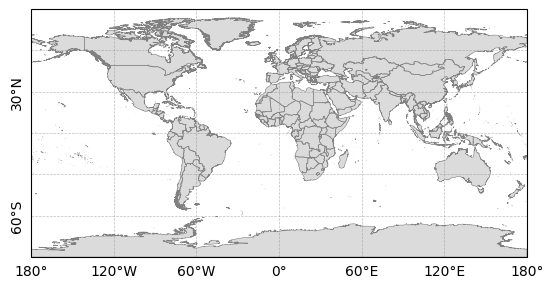

In [91]:
fig, ax = create_map()

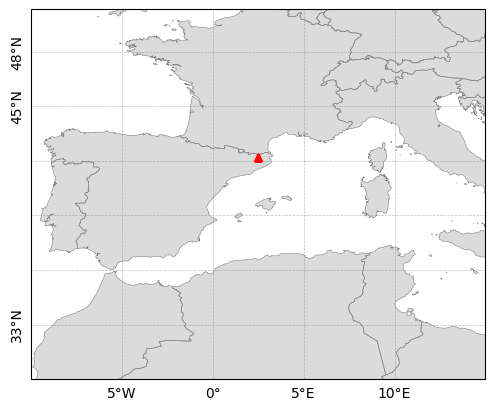

In [9]:
fig, ax = create_map()
###
### Set map limits
###
ax.set_extent([-10, 15, 30, 50]) # [x1,x2,y1,y2]
###
### Volcà del Montsacopa
####
vlat, vlon = 42.187193, 2.488525
###
### Add vent location
###
ax.plot(vlon,vlat,color='red',marker='^')

## Plotting filled contours from FALL3D data

[Text(0.5, 1.0, 'Ensemble mean')]

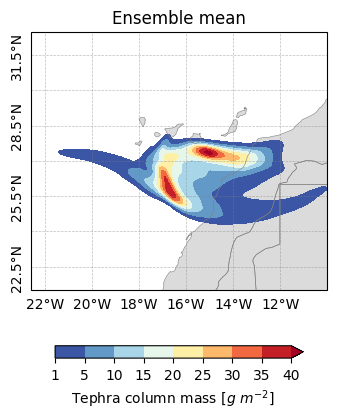

In [10]:
fig, ax = create_map()

fc = ax.contourf(
    da.lon,da.lat,da,
    levels    = [1, 5, 10, 15, 20, 25, 30, 35, 40],
    cmap      = plt.cm.RdYlBu_r,
    extend    = 'max',
    transform = proj
    )

cbar=fig.colorbar(
    fc, 
    orientation = 'horizontal',
    label = r'Tephra column mass [$g~m^{-2}$]',
    shrink = 0.5,                  
)
ax.set(title='Ensemble mean')

## Exercise: Exceedance probabilities

<div class="alert alert-block alert-info">
<b>Exercise:</b> Given an ensemble of column mass forecasts:
    
* Compute exceedance probabilities for an intensity threshold of 10 g/m2
* Plot contour lines for probabilities of 2%, 25%, 50%, 75%, 98%
</div>


In [80]:
threshold = 10

da = ds['tephra_col_mass'].isel(time=-1)
probabilities = 100*(da>threshold).mean(dim='ens')
probabilities

<xarray.DataArray 'tephra_col_mass' (lat: 101, lon: 121)> Size: 98kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(101, 121))
Coordinates:
  * lon      (lon) float32 484B -22.0 -21.9 -21.8 -21.7 ... -10.2 -10.1 -10.0
  * lat      (lat) float32 404B 22.0 22.1 22.2 22.3 22.4 ... 31.7 31.8 31.9 32.0
    time     datetime64[ns] 8B 2025-09-27T09:00:00

[Text(0.5, 1.0, 'Exceedance probabilities')]

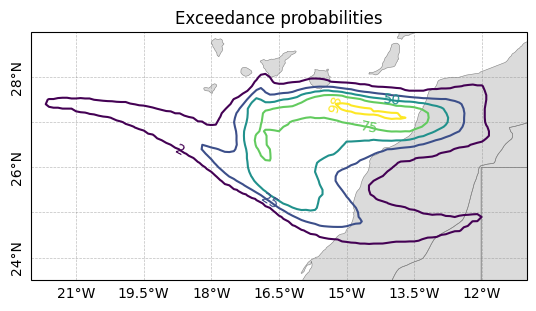

In [88]:
fig, ax = create_map()

cs = ax.contour(
    da.lon,da.lat,probabilities,
    levels    = [2, 25, 50, 75, 98],
    #cmap      = plt.cm.RdYlBu_r,
    #extend    = 'max',
    transform = proj
    )
ax.clabel(cs, cs.levels, inline =False, fontsize=10)
ax.set_extent([-22, -11, 23.5, 29]) # [x1,x2,y1,y2]
ax.set(title='Exceedance probabilities')